In [1]:
import pandas as pd
import numpy as np
import random as rn
import matplotlib.pyplot as plt
import networkx as nx
import utils_causal
from dowhy import CausalModel
from castle.algorithms import PC
from castle.common import GraphDAG

c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-07 15:01:41,376 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\backend\__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
2026-08-07 15:01:41,438 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\castle\algorithms\__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


Defining a function to run PC algorithm everytime

In [2]:
def run_pc (df, alpha, ci_test):
    """Runs PC algorithm"""

    pc = PC(alpha=alpha, ci_test=ci_test)
    pc.learn(df)

    return pc.causal_matrix

Defining a function to find nodes and edges

* nodes=df.columns
* matrix=pc.causal_matrix

In [3]:
def make_nodes_and_edges (nodes,matrix):
    """Finds nodes and edges"""
    import utils_causal

    nodes_labels = [(n, n) for n in nodes]

    edges = []
    for i, start_node in enumerate(nodes):
        for j, end_node in enumerate(nodes):
            if matrix[i, j] == 1:
                edges.append((start_node, end_node))
    return nodes_labels, edges

Defining a function to make a DAG

In [4]:
def make_DAG (nodes_labels,edges):
    """Makes the DAG"""

    import utils_causal

    model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)

    model_test.view_model()

Defining a function to make our custom DAG using the adjacency matrix

In [5]:
def make_custom_DAG (matrix, nodes_labels,title,savefig):
    """Makes the custom DAG with predefined positions"""

    adj_matrix= np.array(matrix)

    node_names=nodes_labels

    true_matrix= np.array([
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0]
    ])

    G_true=nx.from_numpy_array(true_matrix, create_using=nx.DiGraph)

    mapping={i:node_names[i] for i in range(len(node_names))}
    G_true=nx.relabel_nodes(G_true, mapping)

    G=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

    mapping={i:node_names[i] for i in range(len(node_names))}
    G=nx.relabel_nodes(G, mapping)

    gen_list=list(G.edges())
    true_list=list(G_true.edges())

    G_full=gen_list

    list_of_colors=[]
    line_style=[]

    for a in gen_list:
        if a in true_list:
            edgecolor="Green"
            style="-"
        else:
            edgecolor="Red"
            style="-"
        list_of_colors.append(edgecolor)
        line_style.append(style)

    for b in true_list:
        if b not in gen_list:
            edgecolor="Grey"
            style=":"
            list_of_colors.append(edgecolor)
            line_style.append(style)
            G_full.append(b)

    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D([0], [0], color='green', lw=1, label='Correct'),
        Line2D([0], [0], color='red', lw=1, label='Incorrect'),
        Line2D([0], [0], color='grey', lw=1, label='Missing'),
    ]

    fig, ax = plt.subplots()
    ax.legend(handles=legend_elements, bbox_to_anchor=[1,1],loc="upper left")

    pos={
    "A":(1,1),
    "B":(2,0.85),
    "C":(3,1),
    "D":(4,0.85),
    "E":(5,1),
    "Treatment":(1.5,0),
    "Outcome":(4.5,0)
    }
    
    nx.draw_networkx(
        G,
        pos,
        with_labels=True,
        arrows=True,
        edgelist=G_full,
        edge_color=list_of_colors,
        style=line_style,
        node_size=2200,
        font_size=11,
        arrowsize=18
    )

    plt.title(title)
    plt.savefig(savefig)
    plt.show()


Using the functions defined above for the Reference CSV

2026-08-07 15:10:01,994 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-07 15:10:01,997 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


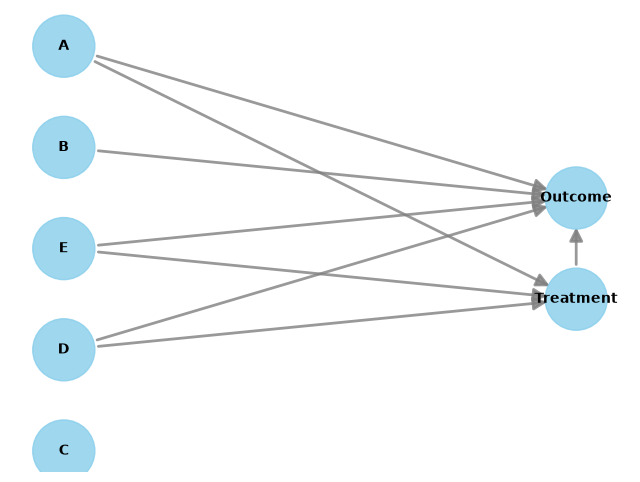

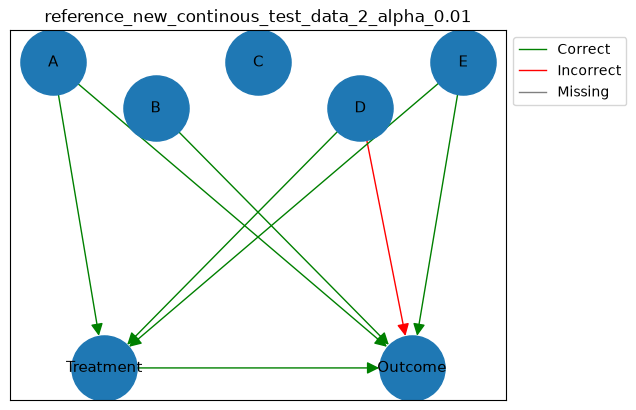

In [ ]:
import os
directory = "Datasets" 
#name of hte folder you want to get the file from
file= "reference_new_continous_test_data_2" 
#name of the file you want to load
file_path = os.path.join(directory, file)
df = pd.read_csv (f"{file_path}.csv") 
#telling it file path so it is able to read csv from there

alpha=0.01 
#alpha value- can be changed everytime; default is 0.05
ci_test="fisherz" 
#fisherz is default; other options include g2, chi2

w= run_pc (df,alpha,ci_test) 
#w will return the pc causal matrix

x1,x2= make_nodes_and_edges (df.columns,w) 
#x1 will return the nodes labels and x2 will return the edges

y= make_DAG(x1,x2)
#y will make the generic dowhy DAG

title=f"{file}_alpha_0.01"

directory = "DAGs"
file_name=f"{file}_DAG_alpha_0.01.png"
file_path = os.path.join(directory, file_name)
savefig=file_path

z=make_custom_DAG (w,df.columns,title,savefig) 
#z will display our custom positional DAG

Using the functions defined above for ATST Continous Data

2026-08-06 13:54:33,149 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-06 13:54:33,150 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


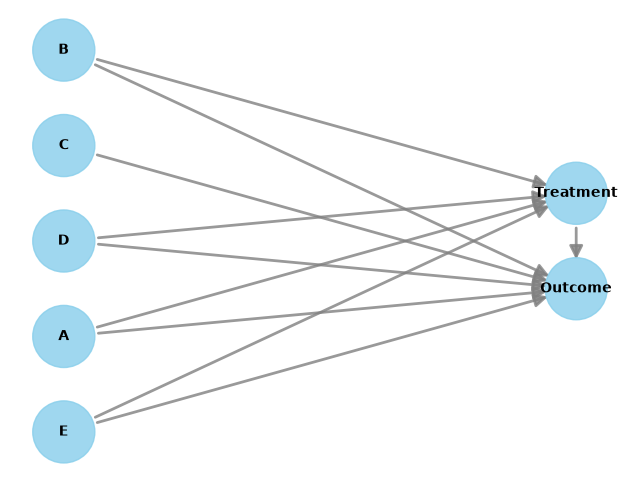

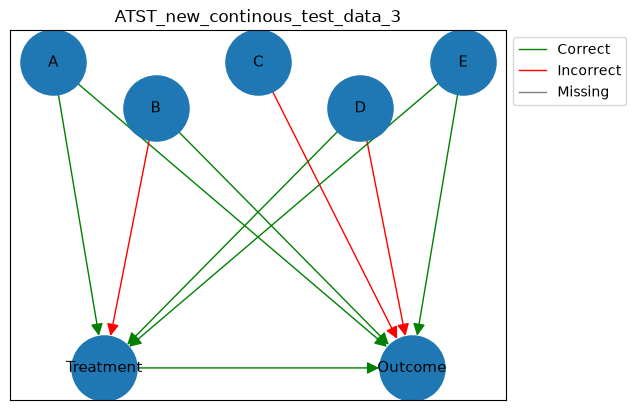

In [ ]:
import os
directory = "Datasets"
file= "ATST_new_continous_test_data_3"
file_path = os.path.join(directory, file)
df = pd.read_csv (f"{file_path}.csv")

alpha=0.05
ci_test="fisherz"
w= run_pc (df,alpha,ci_test) 

x1,x2= make_nodes_and_edges (df.columns,w) 

y= make_DAG(x1,x2) 

title=f"{file}"

directory = "DAGs"
file_name=f"{file}_DAG.png"
file_path = os.path.join(directory, file_name)
savefig=file_path

z=make_custom_DAG (w,df.columns,title,savefig) 

Using the functions defined above for DIS Continous Data

2026-08-06 13:54:33,522 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-06 13:54:33,522 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


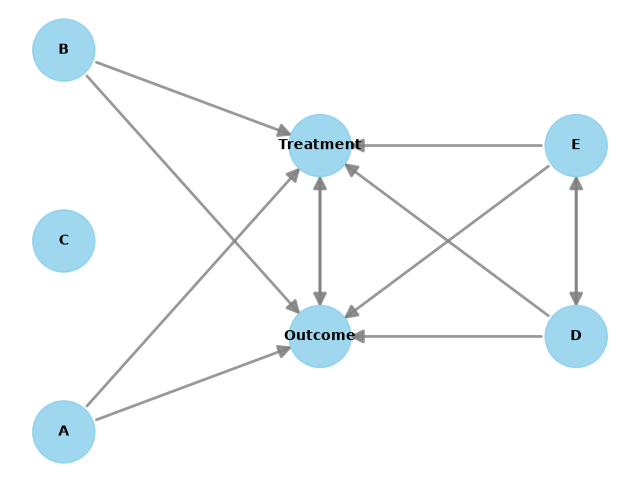

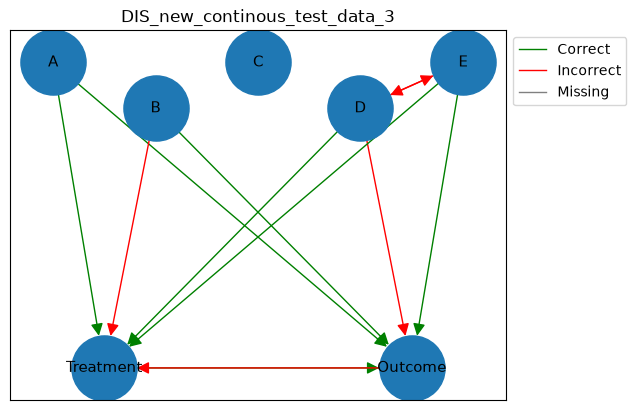

In [ ]:
import os
directory = "Datasets"
file= "DIS_new_continous_test_data_3"
file_path = os.path.join(directory, file)
df = pd.read_csv (f"{file_path}.csv")


alpha=0.05
ci_test="fisherz"
w= run_pc (df,alpha,ci_test) 

x1,x2= make_nodes_and_edges (df.columns,w) 

y= make_DAG(x1,x2) 

title=f"{file}"

directory = "DAGs"
file_name=f"{file}_DAG.png"
file_path = os.path.join(directory, file_name)
savefig=file_path

z=make_custom_DAG (w,df.columns,title,savefig)

Using the functions defined above for SS Continous Data

2026-08-07 15:09:46,598 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-07 15:09:46,601 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


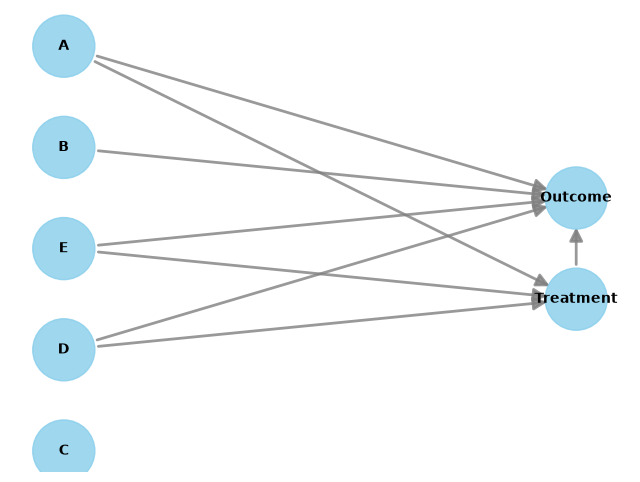

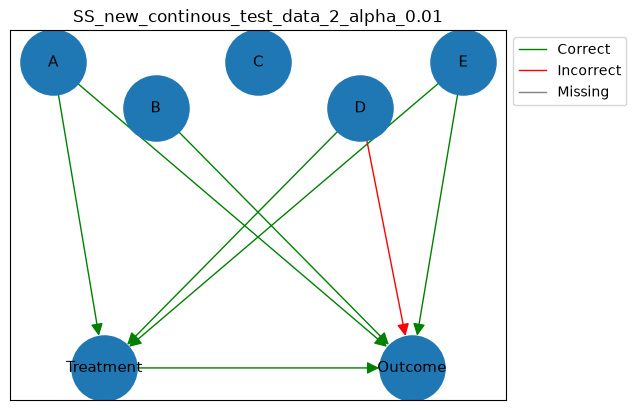

In [ ]:
import os
directory = "Datasets"
file= "SS_new_continous_test_data_2"
file_path = os.path.join(directory, file)
df = pd.read_csv (f"{file_path}.csv")

alpha=0.01
ci_test="fisherz"
w= run_pc (df,alpha,ci_test) 

x1,x2= make_nodes_and_edges (df.columns,w) 

y= make_DAG(x1,x2) 

title=f"{file}_alpha_0.01"

directory = "DAGs"
file_name=f"{file}_DAG_alpha-0.01.png"
file_path = os.path.join(directory, file_name)
savefig=file_path

z=make_custom_DAG (w,df.columns,title,savefig) 